In [1]:

import pandas as pd
import numpy as np
import os
import zipfile
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    TerminateOnNaN,
    LearningRateScheduler,
    CSVLogger,
    TensorBoard,
    ReduceLROnPlateau,
    EarlyStopping,
)
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [29]:
import os
import shutil
import random
base_dir = "/kaggle/input/datasets/yuvrajkabadwal/disaster123/Comprehensive Disaster Dataset(CDD)/CDD_Augmented"
target_dir = "/kaggle/working/"


os.makedirs(os.path.join(target_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(target_dir, 'val'), exist_ok=True)
os.makedirs(os.path.join(target_dir, 'test'), exist_ok=True)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
assert train_ratio + val_ratio + test_ratio == 1, "Ratios must sum to 1"
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name) 
    if os.path.isdir(class_path): 
        images = os.listdir(class_path)
        random.shuffle(images) 
        total_images = len(images)
        train_count = int(total_images * train_ratio)
        val_count = int(total_images * val_ratio) 
        train_images = images[:train_count]
        val_images = images[train_count:train_count + val_count]
        test_images = images[train_count + val_count:] 
        os.makedirs(os.path.join(target_dir, 'train', class_name), exist_ok=True)
        os.makedirs(os.path.join(target_dir, 'val', class_name), exist_ok=True)
        os.makedirs(os.path.join(target_dir, 'test', class_name), exist_ok=True)
        for image in train_images:
            shutil.copy(os.path.join(class_path, image), os.path.join(target_dir, 'train', class_name, image))
        for image in val_images:
            shutil.copy(os.path.join(class_path, image), os.path.join(target_dir, 'val', class_name, image))
        for image in test_images:
            shutil.copy(os.path.join(class_path, image), os.path.join(target_dir, 'test', class_name, image))
print("Dataset into train, val and test")

Dataset into train, val and test


In [5]:

train_dir = '/kaggle/working/train/'
val_dir = '/kaggle/working/val/'
test_dir = '/kaggle/working/test/'

def check_images(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            try:
                img_path = os.path.join(root, file)
                img = Image.open(img_path)
                img.verify()  
            except Exception as e:
                os.remove(img_path)
                print(f"Corrupted image: {img_path}, Error: {e}")

check_images(train_dir)  
check_images(val_dir)    
check_images(test_dir)  
print("CHECK DONE")

CHECK DONE


In [8]:
!rm /kaggle/input/datasets/yuvrajkabadwal/disaster123/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Damaged_Infrastructure/10042.jpg

/bin/bash: -c: line 0: syntax error near unexpected token `('
/bin/bash: -c: line 0: `rm /kaggle/input/datasets/yuvrajkabadwal/disaster123/Comprehensive Disaster Dataset(CDD)/CDD_Augmented/Damaged_Infrastructure/10042.jpg'


In [13]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = '/kaggle/working/train/'
val_dir = '/kaggle/working/val/'
test_dir = '/kaggle/working/test/'


img_height, img_width = 150, 150  
batch_size = 32


train_datagen = ImageDataGenerator(
    rescale=1.0/255, 
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical' 
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False 
)

# Define a simple CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(train_generator.class_indices), activation='softmax') 
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=10  
)


test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test accuracy: {test_accuracy:.2f}')



Found 12810 images belonging to 6 classes.
Found 2743 images belonging to 6 classes.
Found 2750 images belonging to 6 classes.


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 402s 993ms/step - accuracy: 0.6897 - loss: 1.0588 - val_accuracy: 0.7066 - val_loss: 0.9674
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 491us/step - accuracy: 0.5938 - loss: 1.1020 - val_accuracy: 0.5217 - val_loss: 1.1042
Epoch 3/10


/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


400/400 ━━━━━━━━━━━━━━━━━━━━ 395s 983ms/step - accuracy: 0.7083 - loss: 0.8769 - val_accuracy: 0.7210 - val_loss: 0.7958
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7500 - loss: 0.6365 - val_accuracy: 0.7391 - val_loss: 0.9830
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 387s 961ms/step - accuracy: 0.7090 - loss: 0.8174 - val_accuracy: 0.7320 - val_loss: 0.7818
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step - accuracy: 0.7188 - loss: 0.6810 - val_accuracy: 0.9130 - val_loss: 0.2950
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 389s 966ms/step - accuracy: 0.7231 - loss: 0.7839 - val_accuracy: 0.7537 - val_loss: 0.6945
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7812 - loss: 0.6245 - val_accuracy: 0.6522 - val_loss: 0.9320
Epoch 9/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 391s 971ms/step - accuracy: 0.7524 - loss: 0.7199 - val_accuracy: 0.7801 - val_loss: 0.6634
Epoch 10/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 373us/step - accuracy: 0.9062 - loss: 0.3898 - va

In [23]:
model.save('image_classification_model.h5')  

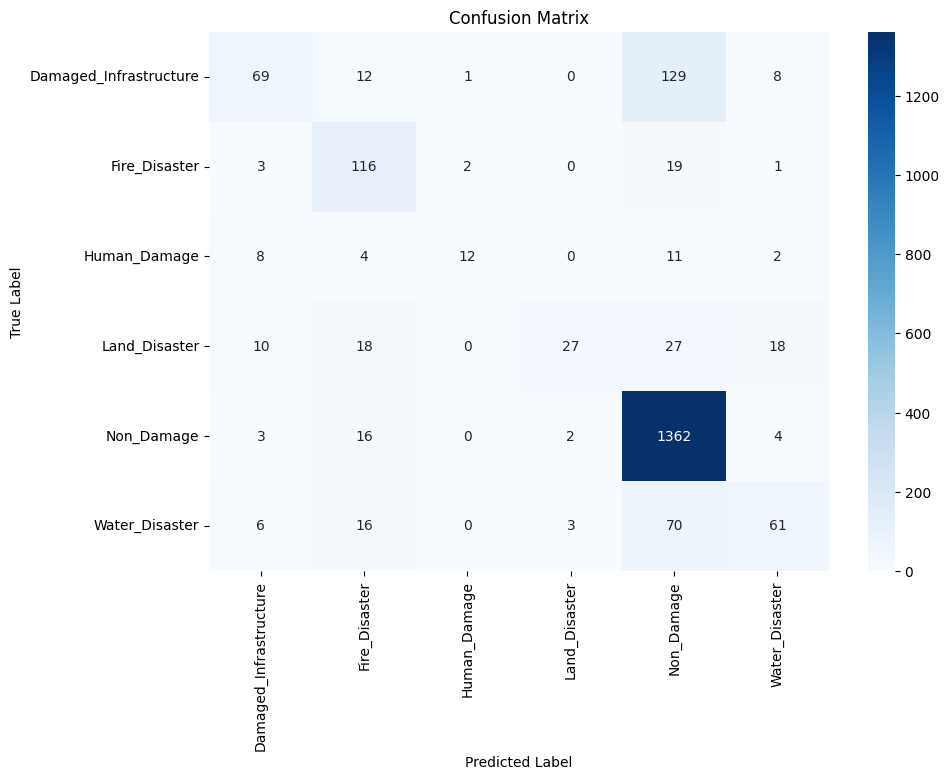

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
confusion_matrix = np.array([[  69,   12,    1,    0,  129,    8],
                              [   3,  116,    2,    0,   19,    1],
                              [   8,    4,   12,    0,   11,    2],
                              [  10,   18,    0,   27,   27,   18],
                              [   3,   16,    0,    2, 1362,    4],
                              [   6,   16,    0,    3,   70,   61]])

# Define class labels
class_labels = ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [25]:
class_names = train_generator.class_indices
print(class_names)

{'Damaged_Infrastructure': 0, 'Fire_Disaster': 1, 'Human_Damage': 2, 'Land_Disaster': 3, 'Non_Damage': 4, 'Water_Disaster': 5}


In [28]:
model_path = '/kaggle/working/my_final_model.keras'
zip_file_path = '/kaggle/working/my_final_model.zip'

# Create a zip file containing the model
with zipfile.ZipFile(zip_file_path, 'w') as zipf:
    zipf.write(model_path, os.path.basename(model_path))